# Demo RNN và LSTM

**Mục tiêu:** 
Demo ứng dụng của Mạng nơ-ron hồi quy (RNN) và Long Short-Term Memory (LSTM) trong bài toán **Sequence Classification**.

**Dataset:** 
**IMDB Movie Reviews** (Có sẵn trên Kaggle). Dữ liệu bao gồm các đánh giá phim ảnh được gán nhãn Tích cực (Positive - 1) hoặc Tiêu cực (Negative - 0).

**Kiến trúc xây dựng:**
1. Lớp Embedding (Đại diện vector từ vựng)
2. Lớp RNN / LSTM (Trích xuất đặc trưng chuỗi)
3. Lớp Dense / Feedforward 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Bidirectional

print("TensorFlow Version:", tf.__version__)

2026-05-07 16:12:30.891037: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778170351.208408      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778170351.298315      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778170352.063752      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778170352.063807      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778170352.063810      16 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


## 1. Load và Tiền xử lý dữ liệu (Data Preprocessing)

Trong RNN, các văn bản đầu vào cần được chuyển thành các chuỗi số (mỗi số đại diện cho một từ trong từ điển). Tập dataset IMDB của Keras đã làm sẵn bước này.

In [2]:
# Cấu hình
vocab_size = 10000  # Chỉ lấy 10,000 từ xuất hiện nhiều nhất
max_length = 200    # Giới hạn mỗi bình luận chỉ lấy tối đa 200 từ (để train nhanh hơn)

# Load data
print("Đang tải dữ liệu IMDB...")
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print(f"Số lượng mẫu huấn luyện: {len(X_train)}")
print(f"Số lượng mẫu kiểm thử: {len(X_test)}")

# Xem thử 1 mẫu dữ liệu dạng số
print("\nMẫu review đầu tiên (dạng index):", X_train[0][:15], "...")

Đang tải dữ liệu IMDB...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Số lượng mẫu huấn luyện: 25000
Số lượng mẫu kiểm thử: 25000

Mẫu review đầu tiên (dạng index): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4] ...


Để hiểu mạng Neural nhìn thấy gì, dùng một hàm nhỏ để dịch các con số này ngược lại thành tiếng Anh.
Đồng thời, vì các câu dài ngắn khác nhau, cần dùng kỹ thuật **Padding** để ép tất cả các chuỗi về cùng một độ dài (max_length = 200).

In [3]:
# Lấy từ điển Word Index
word_index = imdb.get_word_index()
# Đảo ngược từ điển để tra cứu từ ID -> Từ
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def decode_review(text):
    # Trừ đi 3 vì các index 0, 1, 2 được dùng cho padding, start, và unknown
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in text])

print("Nội dung gốc của review đầu tiên:\n")
print(decode_review(X_train[0]))
print("\nNhãn:", "Tích cực" if y_train[0] == 1 else "Tiêu cực")

# Padding sequences (Cắt bớt câu dài, thêm số 0 vào câu ngắn)
X_train_padded = pad_sequences(X_train, maxlen=max_length)
X_test_padded = pad_sequences(X_test, maxlen=max_length)

print(f"\nKích thước sau khi padding: X_train: {X_train_padded.shape}, X_test: {X_test_padded.shape}")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Nội dung gốc của review đầu tiên:

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but th

## 2. Xây dựng Mô hình Simple RNN 

- **Embedding Layer:** Chuyển đổi các số nguyên (index) thành vector dense (Word Embeddings).
- **SimpleRNN Layer:** Mạng nơ-ron hồi quy cơ bản (Elman Networks).
- **Dense Layer:** Feedforward network dùng hàm `sigmoid` để đưa ra xác suất 0 (Tiêu cực) hoặc 1 (Tích cực).

In [4]:
rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32, input_length=max_length),
    SimpleRNN(32), # Lớp RNN với 32 hidden units
    Dense(1, activation='sigmoid') # Phân loại nhị phân
])

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.summary()

print("\nBắt đầu huấn luyện Simple RNN...")
rnn_history = rnn_model.fit(X_train_padded, y_train, epochs=3, batch_size=128, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-05-07 16:13:12.387336: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Bắt đầu huấn luyện Simple RNN...
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.5360 - loss: 0.6874 - val_accuracy: 0.6788 - val_loss: 0.6063
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.7850 - loss: 0.4808 - val_accuracy: 0.7866 - val_loss: 0.4599
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.8989 - loss: 0.2591 - val_accuracy: 0.8384 - val_loss: 0.4087


## 3. Xây dựng Mô hình LSTM 

Simple RNN gặp vấn đề **Vanishing Gradients** (Tiêu biến đạo hàm) khi xử lý các chuỗi dài (không nhớ được bối cảnh xa). 
**LSTM (Long Short-Term Memory)** giải quyết việc này bằng các "cổng" (forget gate, add gate, output gate) để quyết định giữ hay bỏ thông tin.

In [5]:
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32, input_length=max_length),
    LSTM(32), # Lớp LSTM thay vì SimpleRNN
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

print("\nBắt đầu huấn luyện LSTM...")
lstm_history = lstm_model.fit(X_train_padded, y_train, epochs=3, batch_size=128, validation_split=0.2)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Bắt đầu huấn luyện LSTM...
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.6388 - loss: 0.6105 - val_accuracy: 0.8428 - val_loss: 0.3731
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - accuracy: 0.8910 - loss: 0.2798 - val_accuracy: 0.8676 - val_loss: 0.3153
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - accuracy: 0.9314 - loss: 0.1865 - val_accuracy: 0.8686 - val_loss: 0.3223


## 4. Mô hình Bidirectional LSTM 

RNN truyền thống đọc từ trái sang phải. **Bidirectional RNN** chạy 2 mạng RNN/LSTM song song: một từ trái sang phải, một từ phải sang trái, giúp mô hình nắm bắt bối cảnh tốt hơn (Ví dụ: hiểu rõ từ phía sau bổ nghĩa cho từ phía trước).

In [6]:
bilstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32, input_length=max_length),
    Bidirectional(LSTM(32)), # Gói LSTM bên trong Bidirectional
    Dense(1, activation='sigmoid')
])

bilstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nBắt đầu huấn luyện Bidirectional LSTM...")
bilstm_history = bilstm_model.fit(X_train_padded, y_train, epochs=3, batch_size=128, validation_split=0.2)


Bắt đầu huấn luyện Bidirectional LSTM...
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 117ms/step - accuracy: 0.6101 - loss: 0.6335 - val_accuracy: 0.8380 - val_loss: 0.3853
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.8717 - loss: 0.3194 - val_accuracy: 0.8750 - val_loss: 0.3206
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - accuracy: 0.9223 - loss: 0.2115 - val_accuracy: 0.8786 - val_loss: 0.3107


## 5. Đánh giá và So sánh kết quả

Vẽ biểu đồ để xem độ chính xác trên tập validation của các mô hình. LSTM và Bi-LSTM sẽ cho kết quả tốt hơn và ổn định hơn Simple RNN trên văn bản dài.

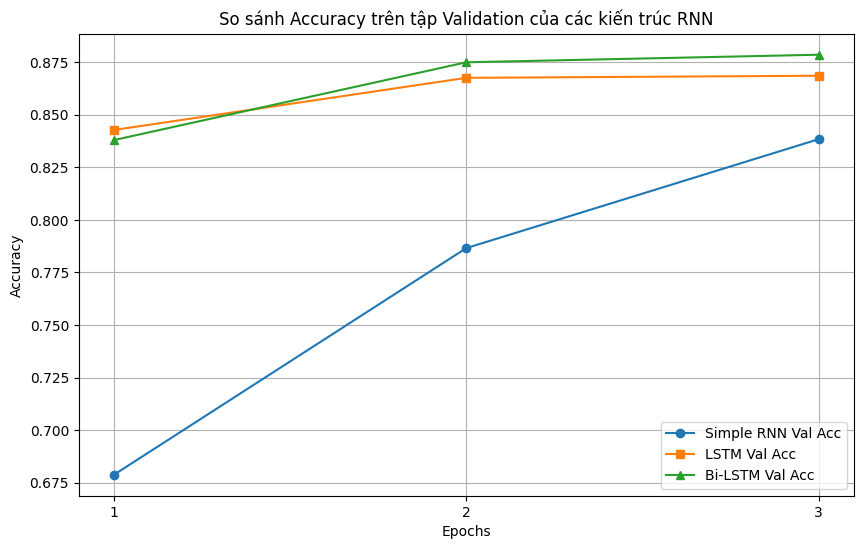

782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8691 - loss: 0.3256
Độ chính xác của Bi-LSTM trên tập Kiểm thử (Test Set): 86.94%


In [7]:
plt.figure(figsize=(10, 6))

plt.plot(rnn_history.history['val_accuracy'], label='Simple RNN Val Acc', marker='o')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM Val Acc', marker='s')
plt.plot(bilstm_history.history['val_accuracy'], label='Bi-LSTM Val Acc', marker='^')

plt.title('So sánh Accuracy trên tập Validation của các kiến trúc RNN')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks([0, 1, 2], ['1', '2', '3'])
plt.legend()
plt.grid(True)
plt.show()

# Đánh giá trên tập test (dùng Bi-LSTM vì thường mạnh nhất)
test_loss, test_acc = bilstm_model.evaluate(X_test_padded, y_test)
print(f"Độ chính xác của Bi-LSTM trên tập Kiểm thử (Test Set): {test_acc*100:.2f}%")

## 6. Chạy thử nghiệm với dữ liệu mới (Inference)

Viết một đoạn review và xem mạng LSTM dự đoán

In [8]:
import re

def predict_sentiment(review_text, model):
    # Tiền xử lý text giống hệt lúc train
    words = re.findall(r'\w+', review_text.lower())
    
    # Chuyển từ thành index
    sequence =[]
    for word in words:
        if word in word_index and word_index[word] < vocab_size:
            sequence.append(word_index[word] + 3) # Cộng 3 vì reserve indices
        else:
            sequence.append(2) # 2 là index của từ Unknown <UNK>
            
    # Padding
    padded_sequence = pad_sequences([sequence], maxlen=max_length)
    
    # Dự đoán
    prediction = model.predict(padded_sequence)[0][0]
    sentiment = "Tích cực (Positive) 😊" if prediction >= 0.5 else "Tiêu cực (Negative) 😞"
    
    print(f"Review: '{review_text}'")
    print(f"Dự đoán: {sentiment} (Độ tự tin: {prediction:.4f})")
    print("-" * 50)

# Chạy thử
predict_sentiment("This movie is absolutely wonderful and the acting is brilliant!", bilstm_model)
predict_sentiment("What a waste of time. The plot was boring and characters were flat.", bilstm_model)
predict_sentiment("The visual effects were good, but the story was terribly written.", bilstm_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
Review: 'This movie is absolutely wonderful and the acting is brilliant!'
Dự đoán: Tích cực (Positive) 😊 (Độ tự tin: 0.9160)
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Review: 'What a waste of time. The plot was boring and characters were flat.'
Dự đoán: Tiêu cực (Negative) 😞 (Độ tự tin: 0.0418)
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Review: 'The visual effects were good, but the story was terribly written.'
Dự đoán: Tiêu cực (Negative) 😞 (Độ tự tin: 0.4480)
--------------------------------------------------
